In [1]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
synth_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
train_ds = filter_by_elev(synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds  = filter_by_elev(meas_ds, {17})

In [6]:
ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

# dataloaders = {x : DataLoader(ds_dict[x], batch_size = 32, num_workers = 5, shuffle = True) for x in ds_dict.keys()}
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

In [7]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

train_loss = []
val_loss = []
train_acc =[]
val_acc = []

for i, seed in enumerate(seed_lst):
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
    # scheduler = OneCycleLR(
    #     optimizer, 
    #     max_lr = 2.5e-4, 
    #     steps_per_epoch = len(dataloaders["train"]), 
    #     epochs = 100
    #     )
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "val_loss" : [],
        "train_acc": [],
        "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.7f} Acc: {epoch_acc:.7f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

        if epoch == 0:
            torch.save(copy.deepcopy(model.state_dict()), os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b16_epoch0.pth"))
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b16.pth"))

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 1.0706211 Acc: 0.6426799
val Loss: 4.0684235 Acc: 0.1228288
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.0713326 Acc: 0.9900744
val Loss: 1.7076379 Acc: 0.4503722
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.0152936 Acc: 1.0000000
val Loss: 2.0557220 Acc: 0.4342432
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.0232701 Acc: 0.9937965
val Loss: 2.6878361 Acc: 0.3585608
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.0436996 Acc: 0.9875931
val Loss: 3.4577455 Acc: 0.2295285
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.0447041 Acc: 0.9913151
val Loss: 1.6678040 Acc: 0.4851117
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.0177192 Acc: 0.9975186
val Loss: 1.0846153 Acc: 0.6439206
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.0080245 Acc: 1.0000000
val Loss: 1.8913009 Acc: 0.5186104
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 0.0020806 Acc: 1.0000000
val Loss: 1.2485014 Acc: 0.6761787
Epoch 8 LR: 0.0002985050
Epoc

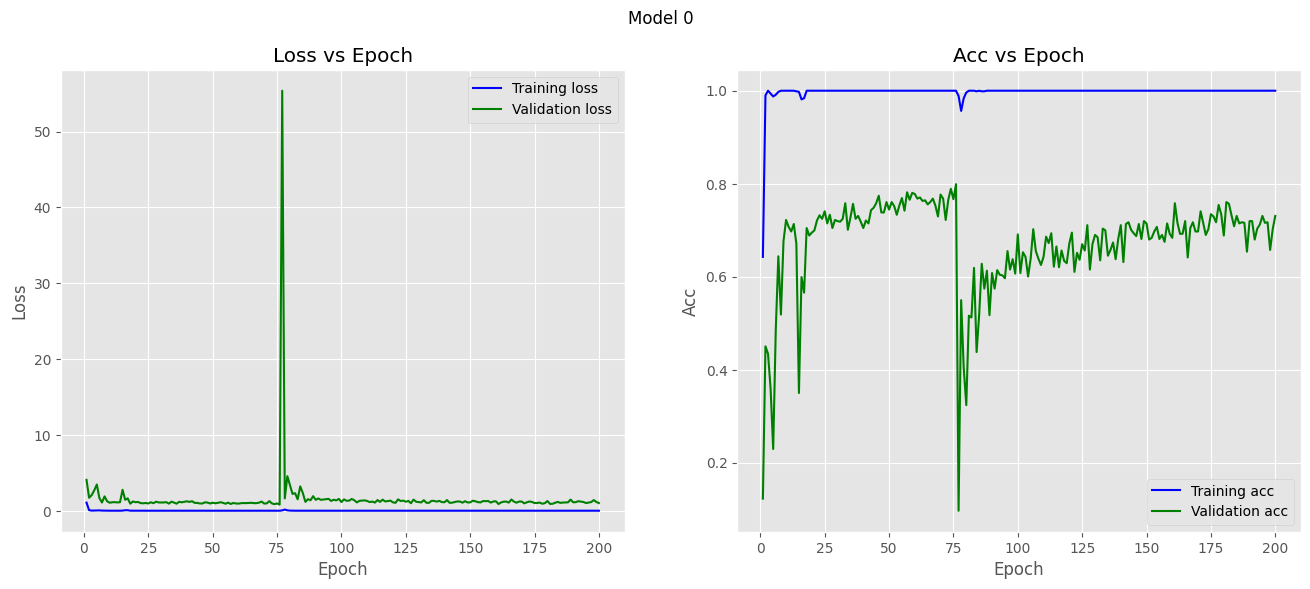

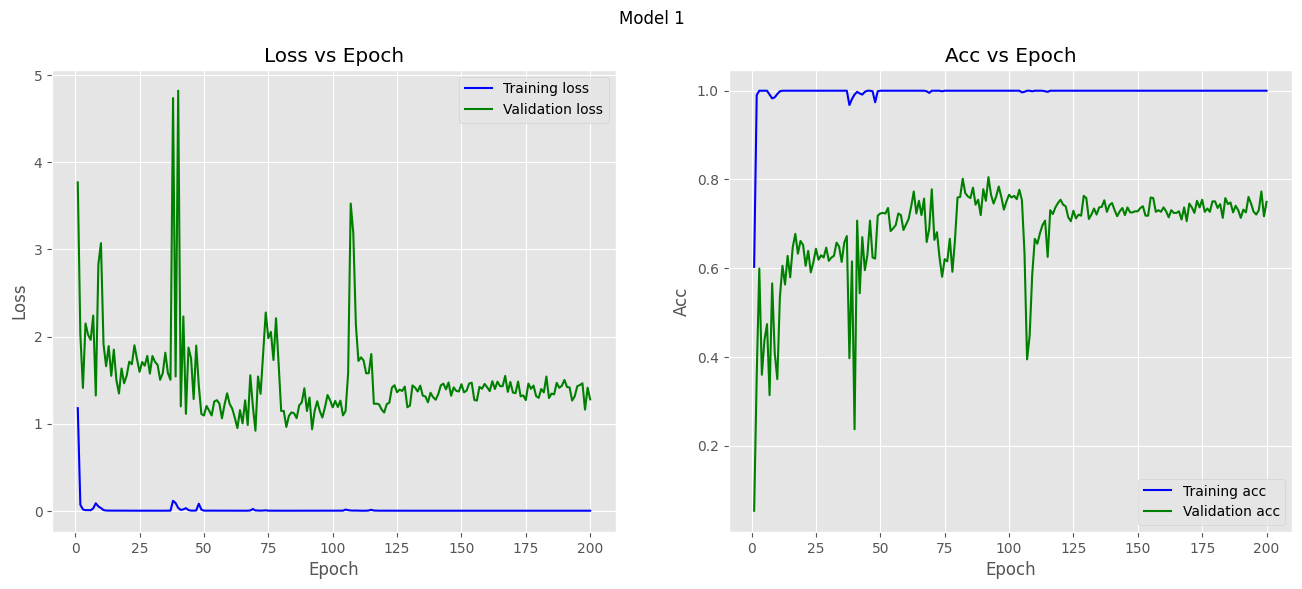

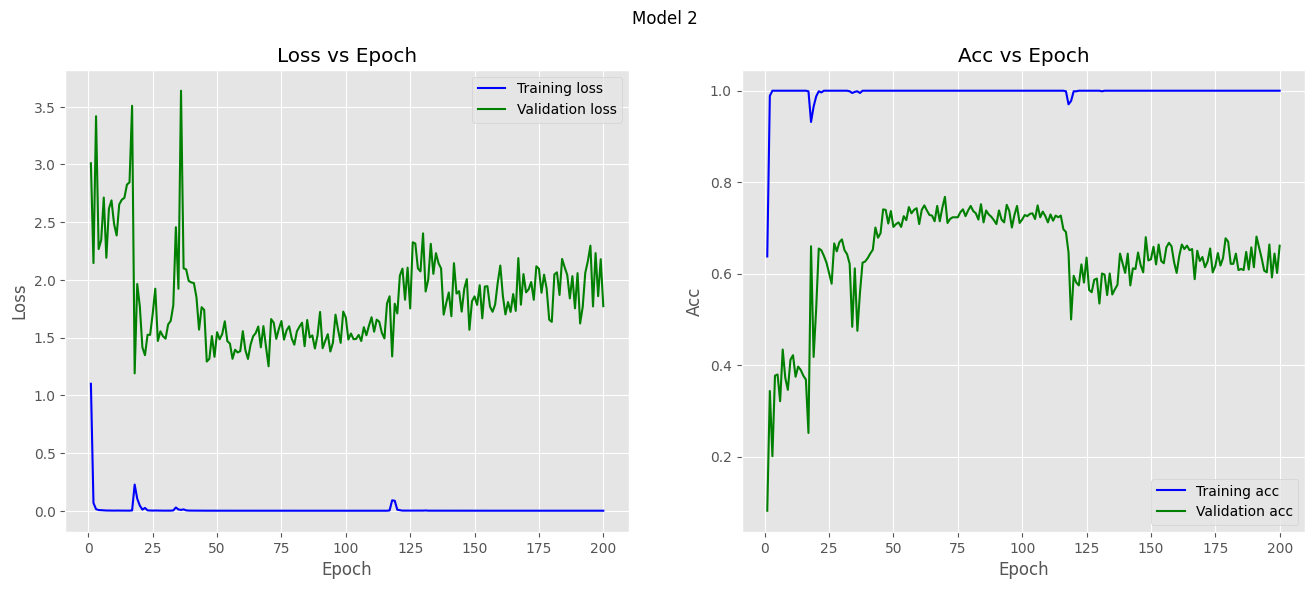

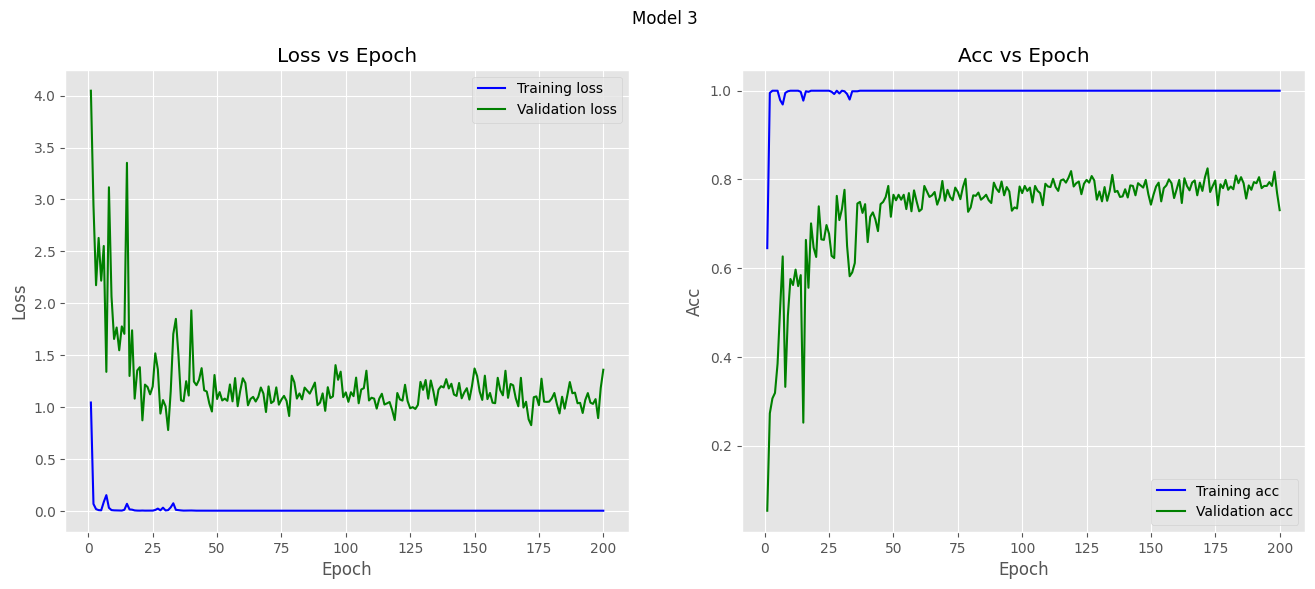

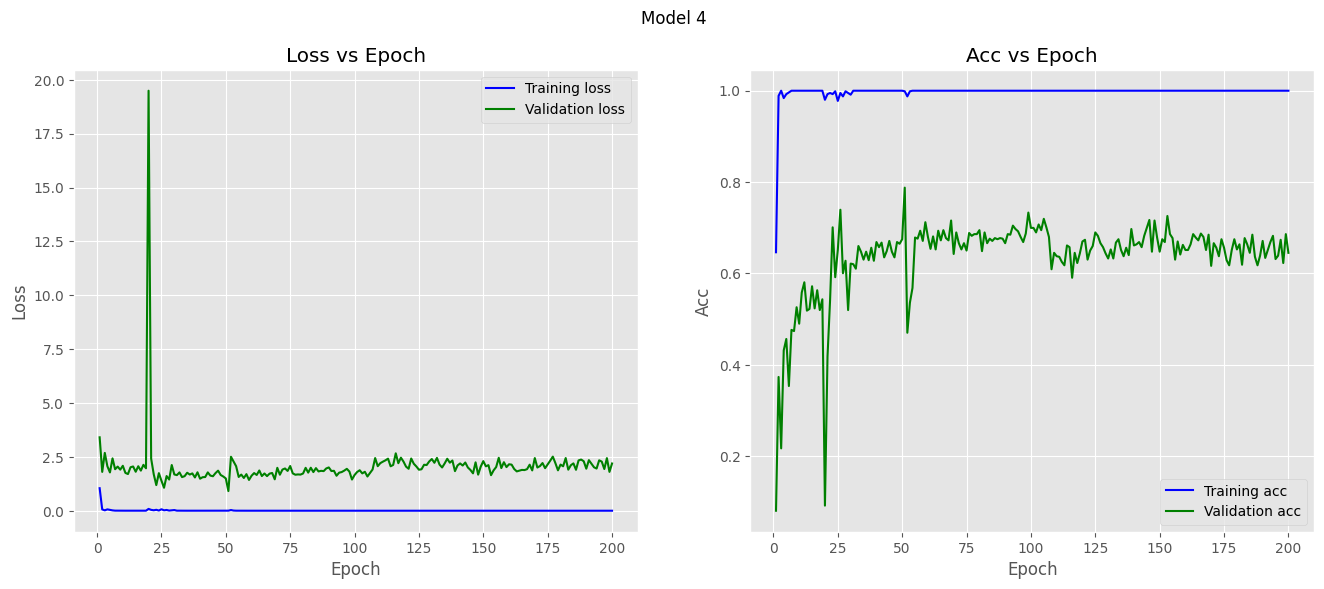

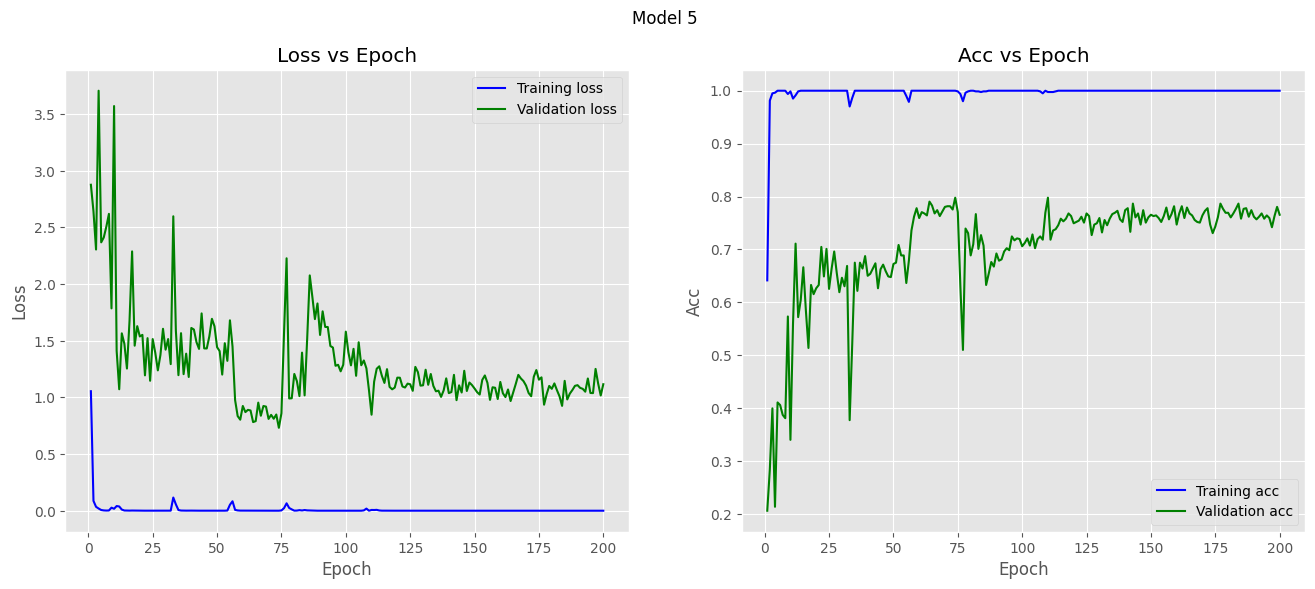

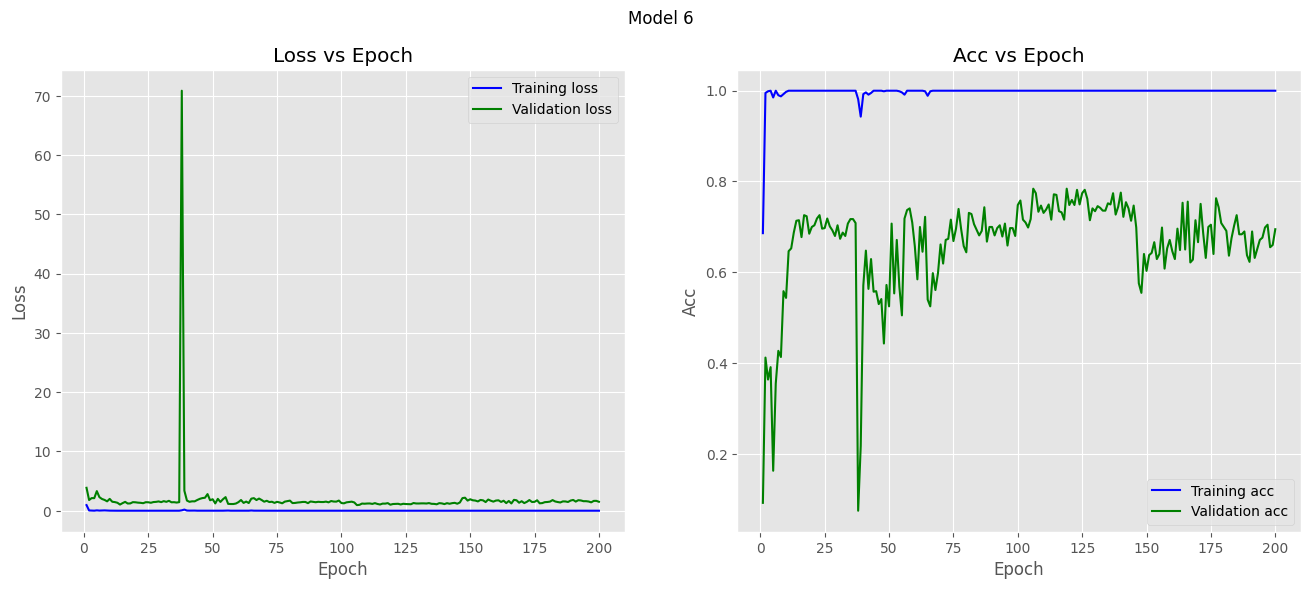

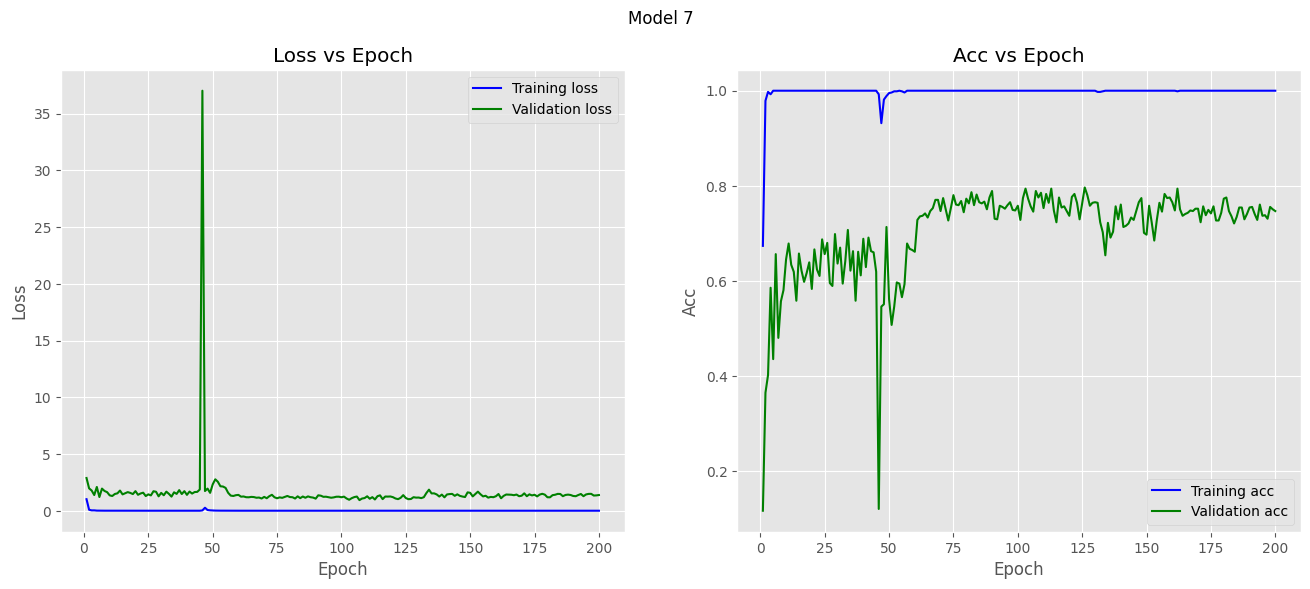

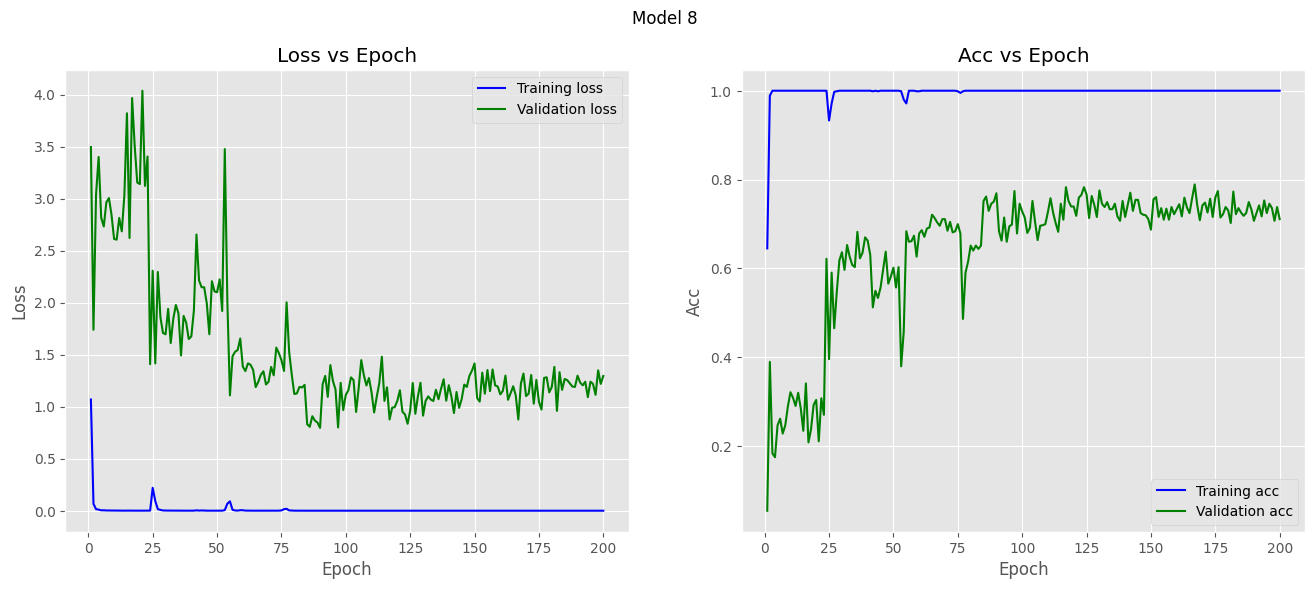

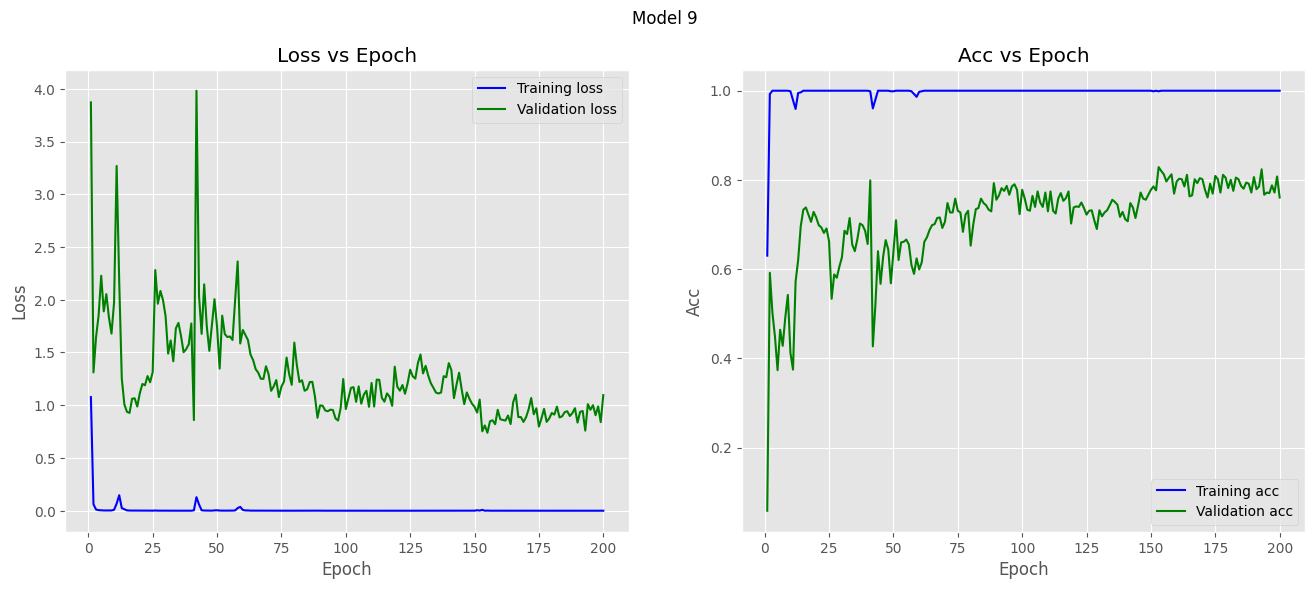

In [8]:
row, col = train_loss.shape

for i in range(row):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Model {i}")
        plt.show()

# Measured 17 Only

In [11]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run{i}_b16_epoch0.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.1224
Evaluating Run 1
Test Accuracy: 0.0909
Evaluating Run 2
Test Accuracy: 0.1373
Evaluating Run 3
Test Accuracy: 0.0909
Evaluating Run 4
Test Accuracy: 0.1150
Evaluating Run 5
Test Accuracy: 0.1985
Evaluating Run 6
Test Accuracy: 0.1224
Evaluating Run 7
Test Accuracy: 0.1614
Evaluating Run 8
Test Accuracy: 0.1020
Evaluating Run 9
Test Accuracy: 0.0983


In [12]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run{i}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.6827
Evaluating Run 1
Test Accuracy: 0.6698
Evaluating Run 2
Test Accuracy: 0.6419
Evaluating Run 3
Test Accuracy: 0.7143
Evaluating Run 4
Test Accuracy: 0.6178
Evaluating Run 5
Test Accuracy: 0.7570
Evaluating Run 6
Test Accuracy: 0.6308
Evaluating Run 7
Test Accuracy: 0.7217
Evaluating Run 8
Test Accuracy: 0.6642
Evaluating Run 9
Test Accuracy: 0.7291


In [13]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 61.7811
Max: 75.6957
Avg, Std: 68.2931, 4.3892


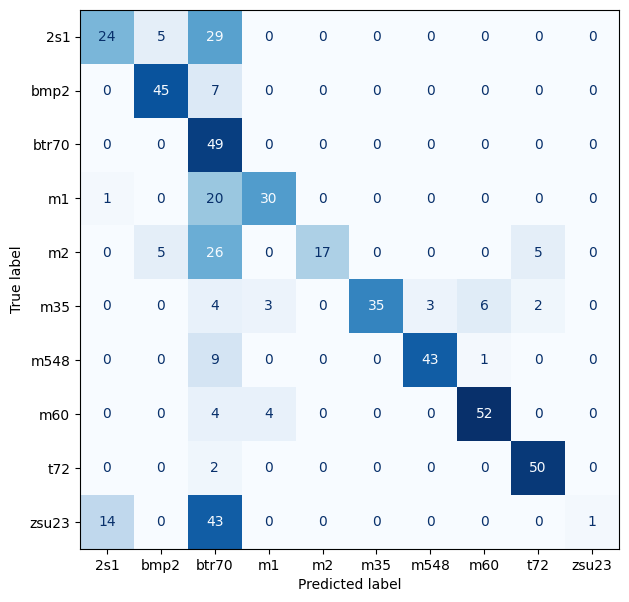

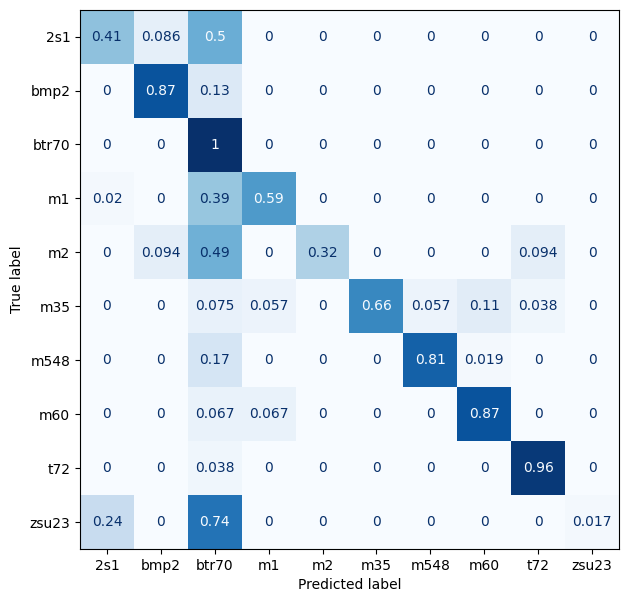

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run2_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()
plt.show()

In [7]:
combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

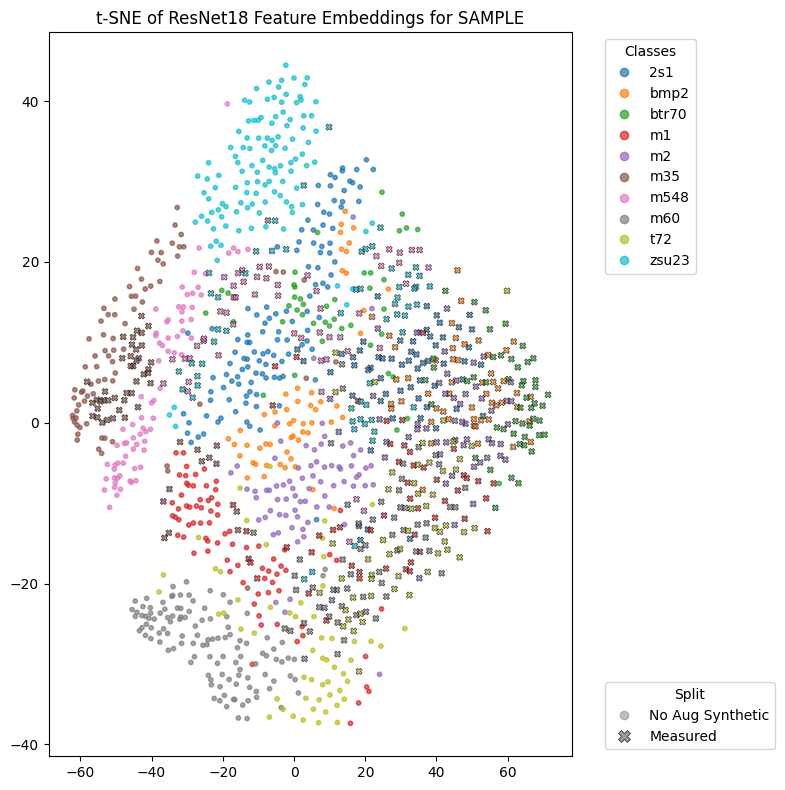

In [8]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run2_b16_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

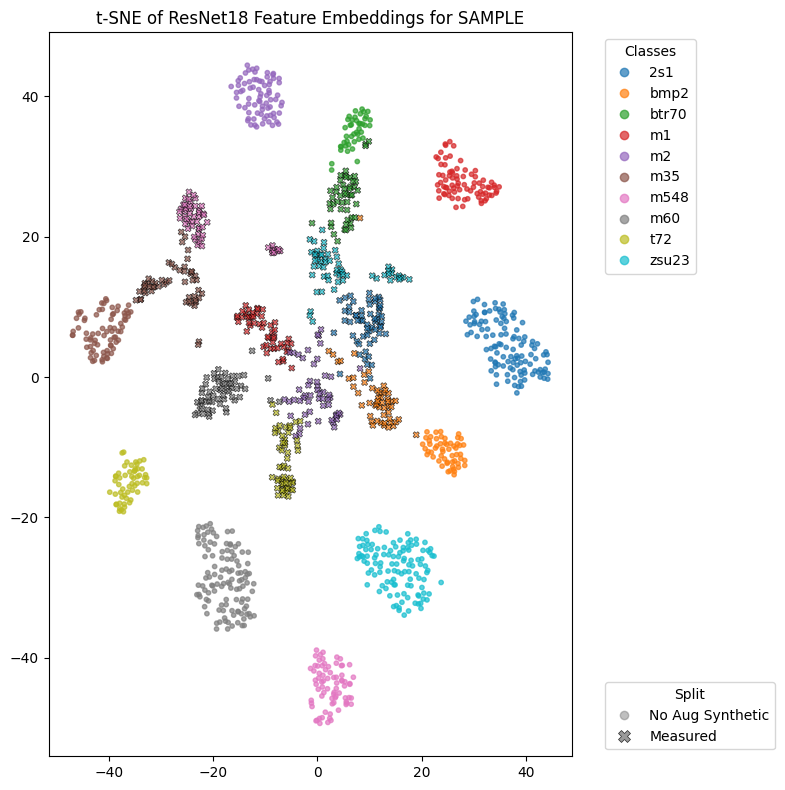

In [9]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run2_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-26 02:53:24.078] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


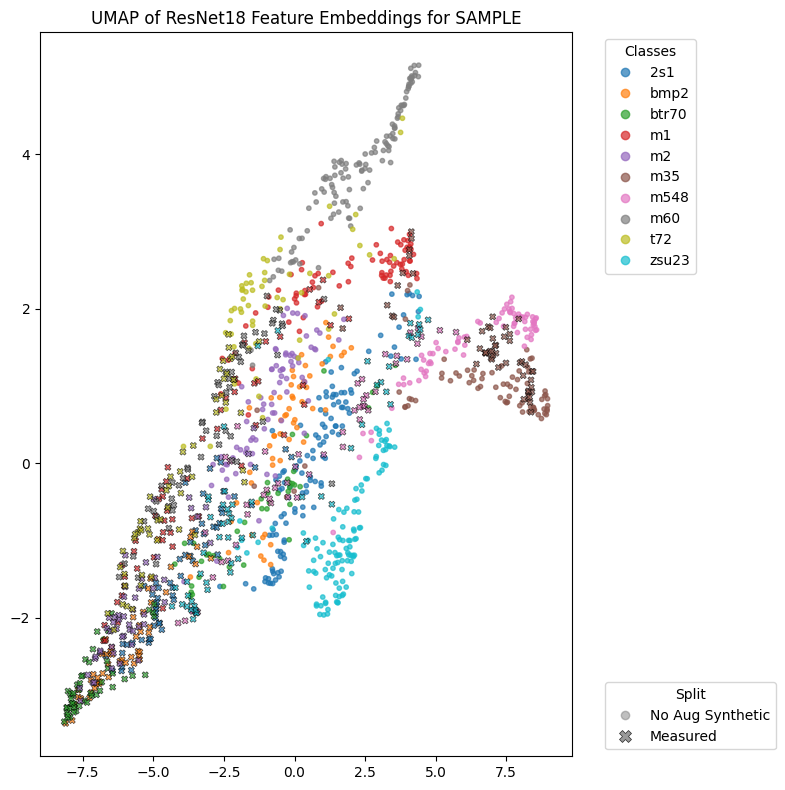

In [10]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run2_b16_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-26 02:53:41.825] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


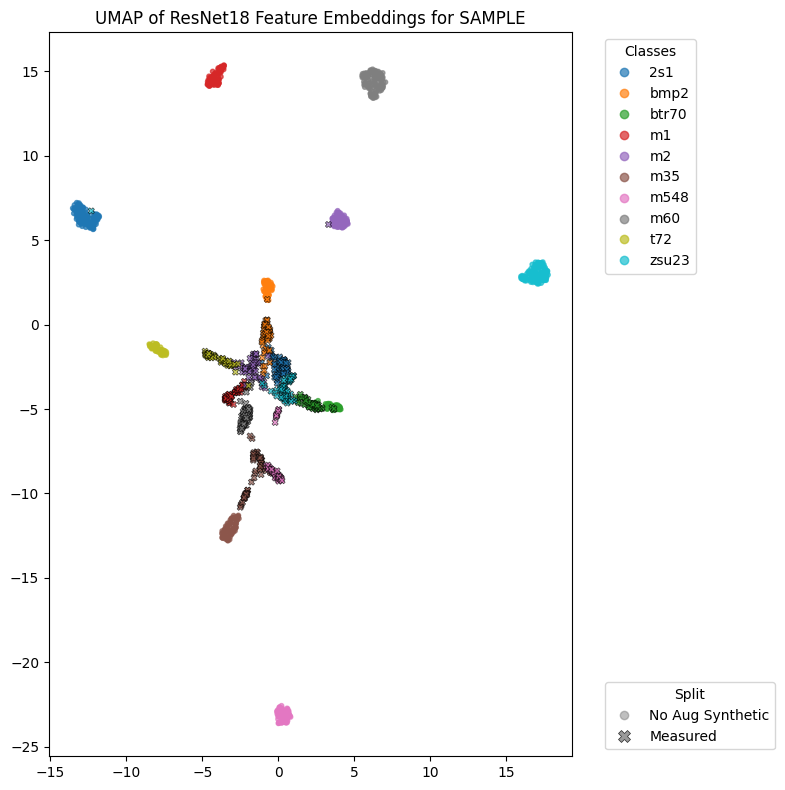

In [11]:
device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run2_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

# Measured 14, 15, 16 and 17

In [8]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run{i}_b16_epoch0.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.1227
Evaluating Run 1
Test Accuracy: 0.0684
Evaluating Run 2
Test Accuracy: 0.1041
Evaluating Run 3
Test Accuracy: 0.0684
Evaluating Run 4
Test Accuracy: 0.0944
Evaluating Run 5
Test Accuracy: 0.2030
Evaluating Run 6
Test Accuracy: 0.1041
Evaluating Run 7
Test Accuracy: 0.1346
Evaluating Run 8
Test Accuracy: 0.0736
Evaluating Run 9
Test Accuracy: 0.0743


In [10]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run{i}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.7115
Evaluating Run 1: Seed 42
Test Accuracy: 0.7175
Evaluating Run 2: Seed 100
Test Accuracy: 0.6535
Evaluating Run 3: Seed 123
Test Accuracy: 0.7242
Evaluating Run 4: Seed 666
Test Accuracy: 0.6342
Evaluating Run 5: Seed 777
Test Accuracy: 0.7621
Evaluating Run 6: Seed 849
Test Accuracy: 0.6691
Evaluating Run 7: Seed 1000
Test Accuracy: 0.7368
Evaluating Run 8: Seed 1111
Test Accuracy: 0.6922
Evaluating Run 9: Seed 1234
Test Accuracy: 0.7480


In [11]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 63.4201
Max: 76.2082
Avg, Std: 70.4907, 3.9738


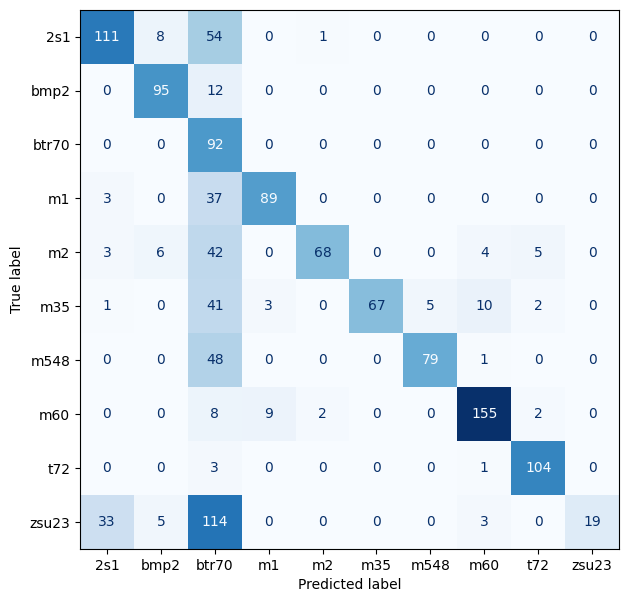

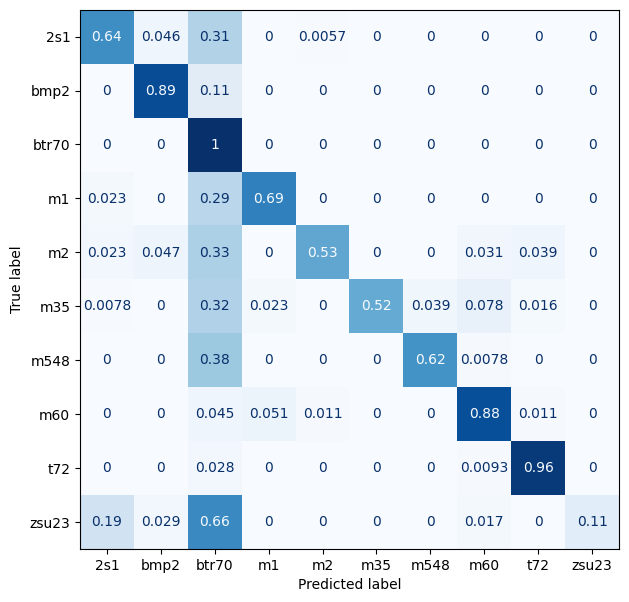

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run2_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(meas_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = synth_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()
plt.show()

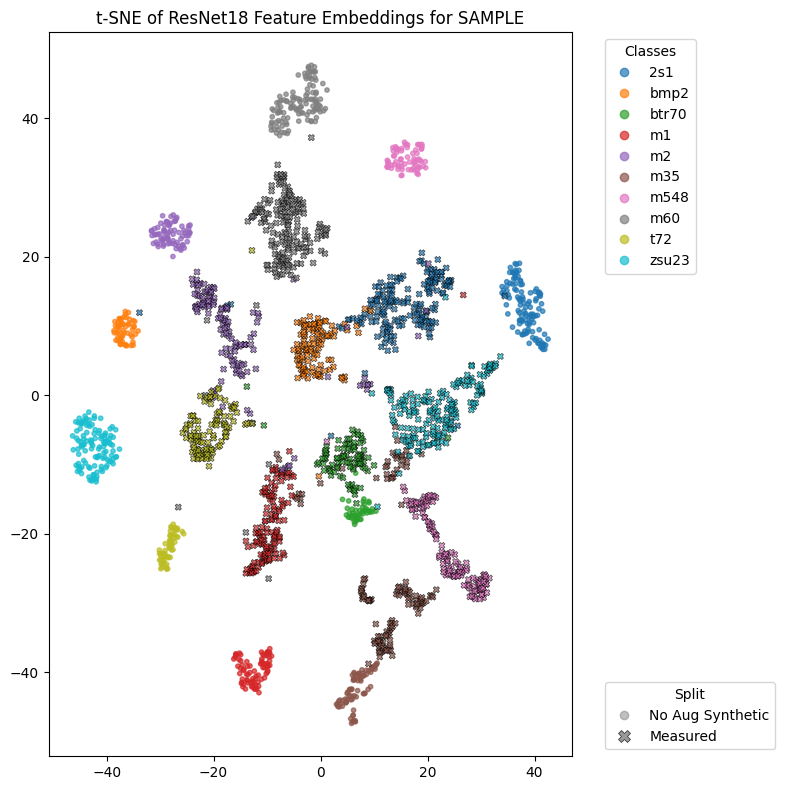

In [8]:
train_plot_ds = train_ds
test_plot_ds = meas_ds

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run2_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive",
    metric = "cosine"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_plot_ds), 0],
    features_2d[:len(train_plot_ds), 1],
    c=labels_list[:len(train_plot_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_plot_ds):, 0],
    features_2d[len(train_plot_ds):, 1],
    c=labels_list[len(train_plot_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-06-20 12:58:07.876] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 25


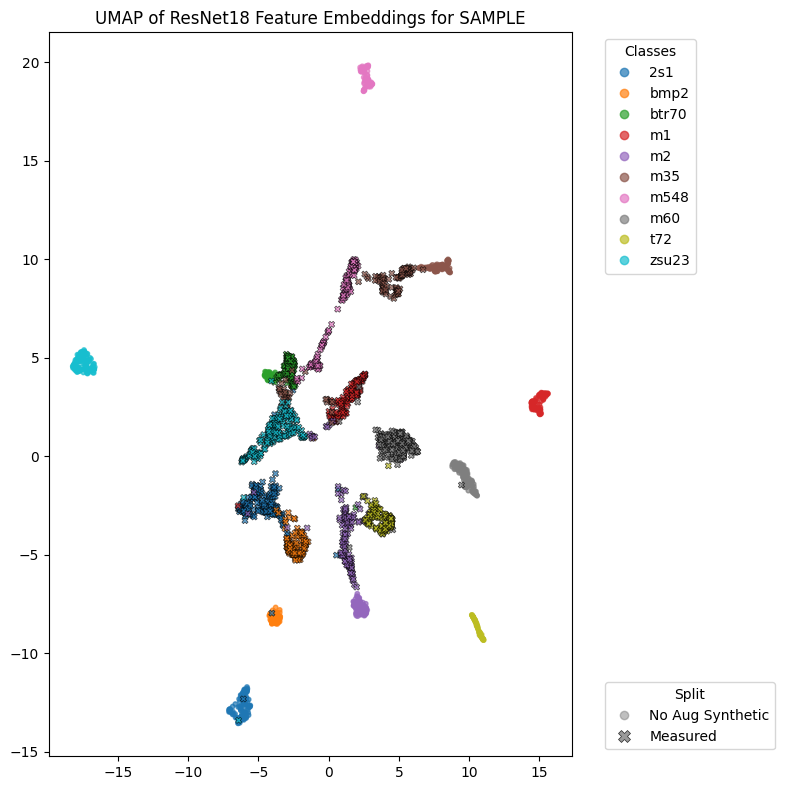

[2026-06-20 12:58:30.652] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 50


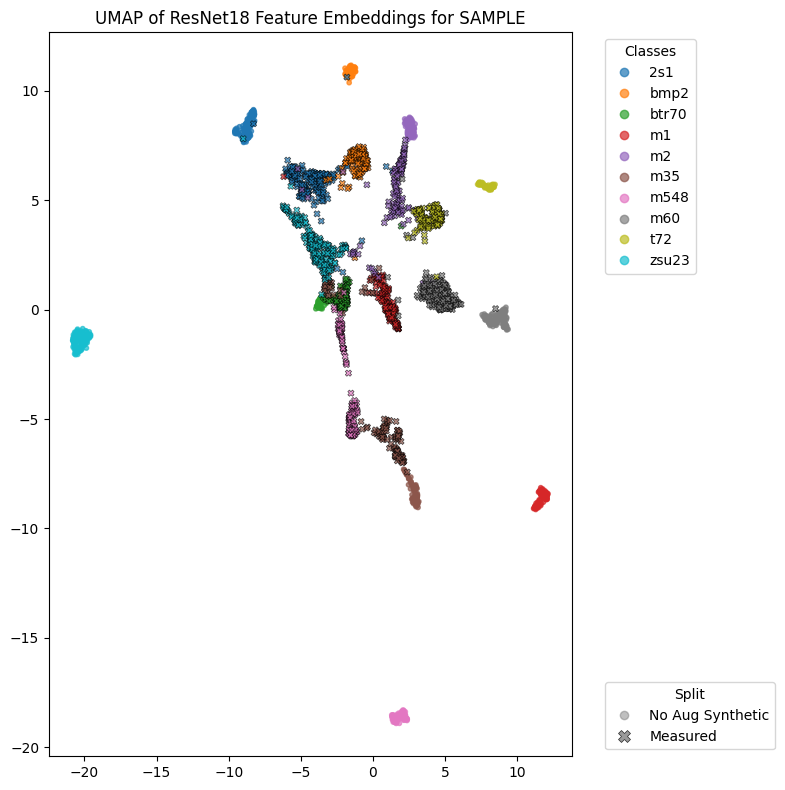

[2026-06-20 12:58:58.473] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 100


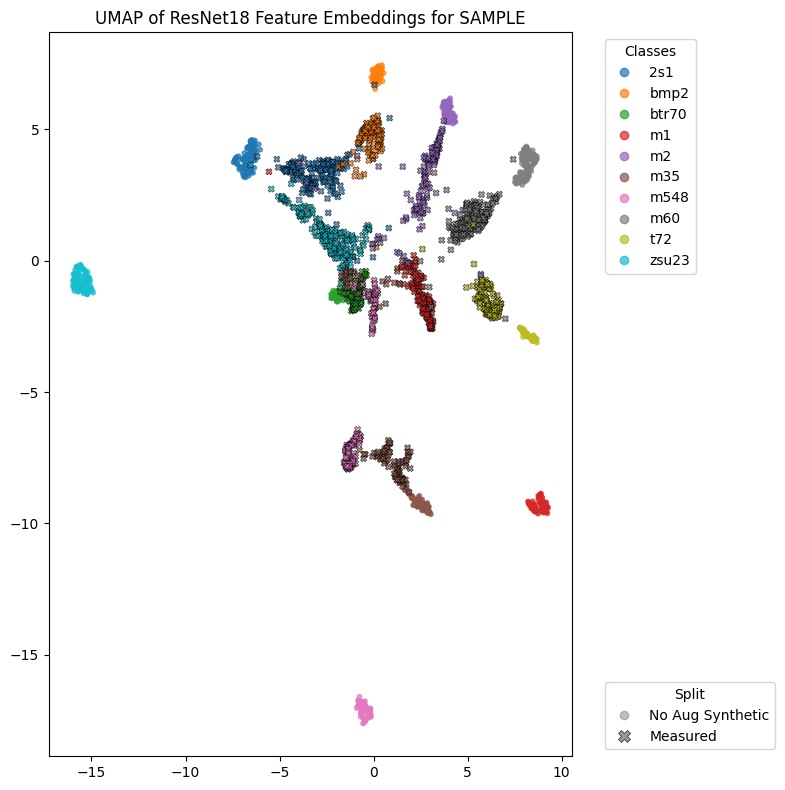

[2026-06-20 12:59:24.283] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 200


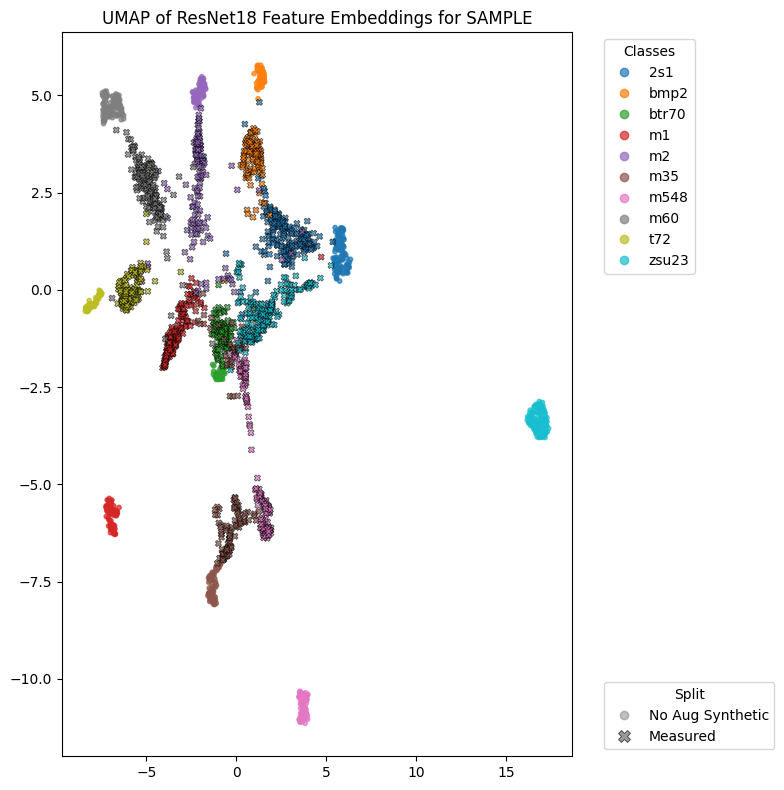

In [ ]:
train_plot_ds = train_ds
test_plot_ds = meas_ds

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])

for num in [25, 50, 100, 200]:

    combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

    device = torch.cuda.set_device("cuda:0")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
        )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run2_b16.pth"),
        map_location=device
    ))

    new_model = new_model.to(device)
    new_model.eval()

    feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()

    features, labels_list = [], []

    with torch.no_grad():
        for inputs, targets in combined_loader:
            inputs = inputs.to(device)
            feats = feature_extractor(inputs)
            feats = feats.view(feats.size(0), -1)
            features.append(feats.cpu())
            labels_list.append(targets)

    features = torch.cat(features).numpy()
    labels_list = torch.cat(labels_list).numpy()

    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(features)

    # Get class names from the dataset
    class_names = [name for name, idx in sorted(train_plot_ds.class_to_idx.items(), key=lambda x: x[1])]

    n_classes = len(class_names)
    
    print(f"UMAP n_neighbours = {num}")

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(train_plot_ds), 0],
        features_2d_umap[:len(train_plot_ds), 1],
        c=labels_list[:len(train_plot_ds)],
        cmap="tab10",
        s=10,
        alpha=0.7,
        marker = "o",
        vmin=0, vmax=n_classes - 1
    )

    plt.scatter(
        features_2d_umap[len(train_plot_ds):, 0],
        features_2d_umap[len(train_plot_ds):, 1],
        c=labels_list[len(train_plot_ds):],
        cmap="tab10",
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k",
        vmin=0, vmax=n_classes - 1
    )

    class_legend = plt.legend(
        handles=scatter.legend_elements()[0],
        labels=class_names,
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    fig.add_artist(class_legend)  # keep it when adding the second legend

    # Marker legend for train vs test
    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
    plt.tight_layout()
    plt.show()

In [8]:
train_ds = filter_by_elev(synth_ds, {14, 15, 16})
test_ds  = filter_by_elev(meas_ds, {17})

device = torch.device("cuda:0")
seed_lst = [(2, 100)]
for i, seed in seed_lst:
    set_seed(seed)
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.classes))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run{i}_b16.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    synth_features, synth_labels, _ = _get_features_and_preds_from_model(model, train_ds, device, seed)
    meas_features, meas_labels, meas_preds = _get_features_and_preds_from_model(model, test_ds, device, seed)

In [9]:
cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(
    meas_features, meas_labels, synth_features, synth_labels, metric = "cosine"
)

Class       q= 1  q= 3  q= 5
----------------------------
2s1         0.083  0.292  0.417  (n=24)
bmp2        0.200  0.378  0.511  (n=45)
btr70       0.224  0.327  0.408  (n=49)
m1          0.333  0.533  0.600  (n=30)
m2          0.471  0.588  0.706  (n=17)
m35         0.229  0.371  0.429  (n=35)
m548        0.256  0.465  0.535  (n=43)
m60         0.135  0.231  0.346  (n=52)
t72         0.220  0.360  0.460  (n=50)
zsu23       0.000  0.000  0.000  (n=1)
----------------------------
Overall     0.223  0.373  0.468  (n=346)
Class       q= 1  q= 3  q= 5
----------------------------
2s1         2.000  7.000  10.000  (n=24)
bmp2        9.000  17.000  23.000  (n=45)
btr70       11.000  16.000  20.000  (n=49)
m1          10.000  16.000  18.000  (n=30)
m2          8.000  10.000  12.000  (n=17)
m35         8.000  13.000  15.000  (n=35)
m548        11.000  20.000  23.000  (n=43)
m60         7.000  12.000  18.000  (n=52)
t72         11.000  18.000  23.000  (n=50)
zsu23       0.000  0.000  0.000  (

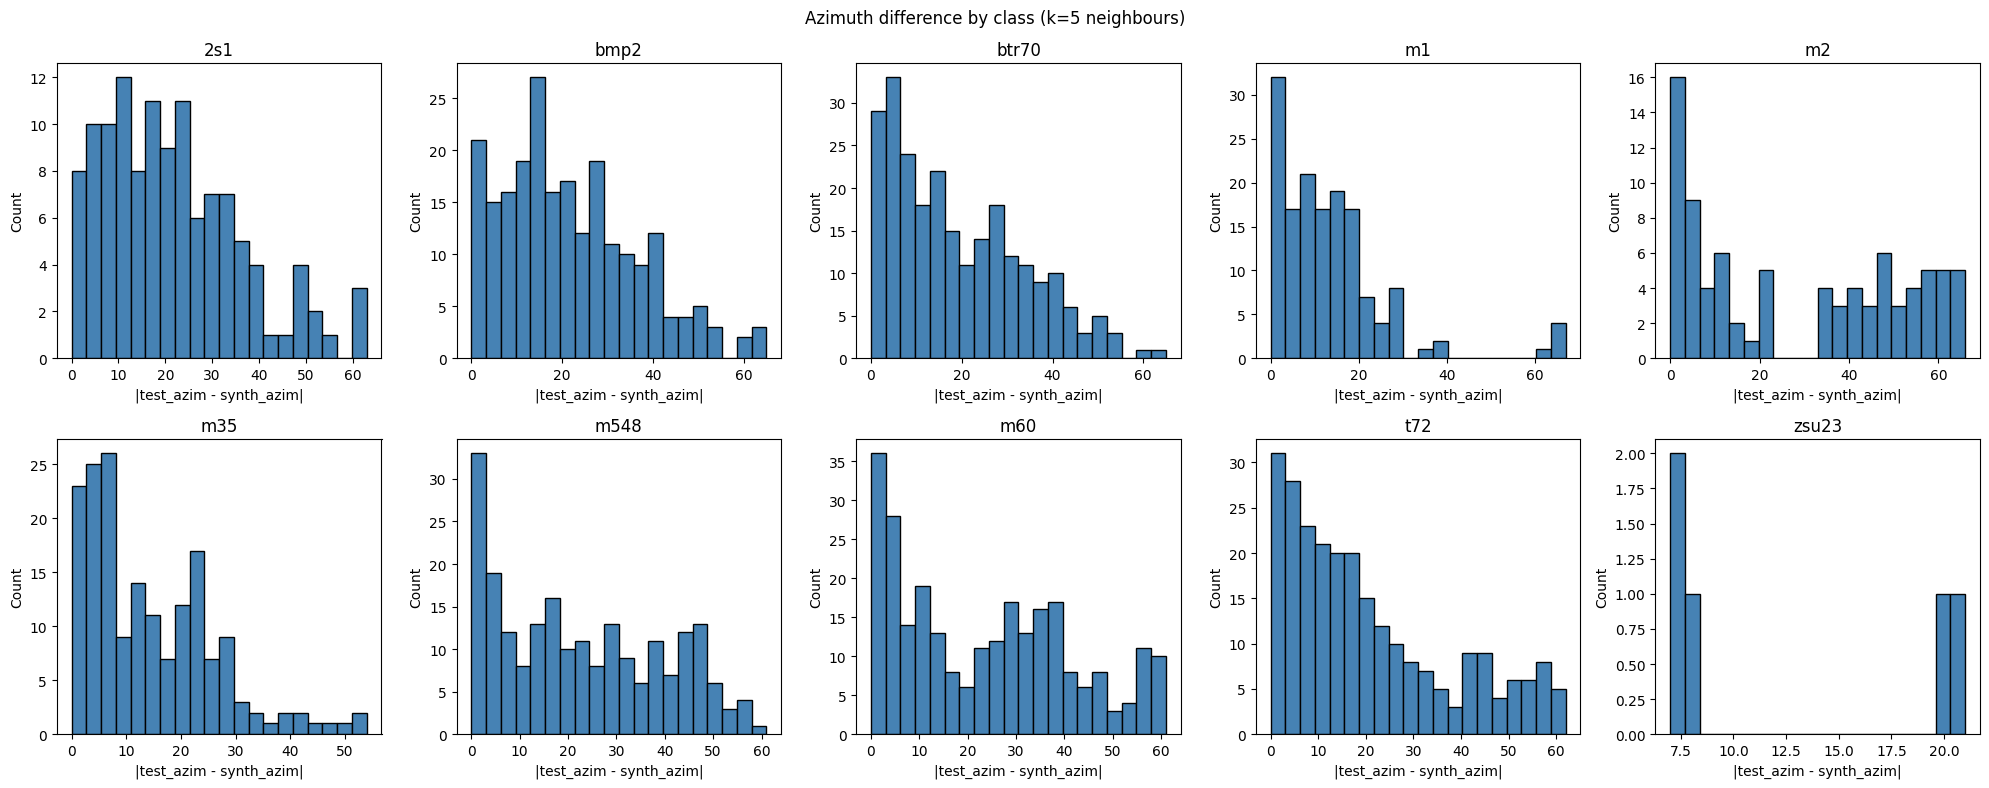

In [11]:
results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, meas_labels, meas_preds,
    train_ds, cosine_n_true_class,
    q_values=[1, 3, 5],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, meas_labels, meas_preds,
    train_ds, cosine_n_true_class,
    q_values=[1, 3, 5], k = 5, normalise = False
)

results, azim_diffs = cp.asnumpy(results), cp.asnumpy(azim_diffs)

correct_mask    = cp.asnumpy(meas_preds) == cp.asnumpy(meas_labels)
correct_classes = cp.asnumpy(meas_labels)[np.where(correct_mask)[0]]
plot_azim_diffs_by_class(test_ds, azim_diffs, correct_classes)